In [169]:
using Plots,JLD2,LinearAlgebra

In [170]:
Nx=20
Ny=20
tper=0.37

tpa=2.0
tNNN=0.16

α=-1.3
temp=0.01
β=-1.3
K=1.0;
KNNN=1.0;
γ=0.0
trytime_record=1

filling=1.25
#trytime=1

1.25

In [171]:
st=load("$(Nx)Nx$(Ny)Ny$(tper)tper$(tpa)tpa$(tNNN)tNNN$(α)alpha$(β)beta$(K)K$(KNNN)KNNN$(filling)filling$(γ)gamma$(temp)temp$(trytime_record)try.jld2")
   

Dict{String, Any} with 12 entries:
  "Eelec"          => -2.66096
  "spectrum"       => [-4.74028, -4.74028, -4.72273, -4.72273, -4.72254, -4.722…
  "max_record"     => 0.500417
  "average_record" => 0.363989
  "orbital_id"     => [1 21 … 361 381; 2 22 … 362 382; … ; 19 39 … 379 399; 20 …
  "phonon_id"      => [1 21 … 361 381; 2 22 … 362 382; … ; 19 39 … 379 399; 20 …
  "phonon_coor"    => [0.0957968, -0.457777, 0.45797, -0.0964162, -0.378032, 0.…
  "FL"             => 1.72643
  "ave_npa"        => 500.0
  "E_total"        => -2.4361
  "Egap"           => 0.0311734
  "free_energy"    => -2.43619

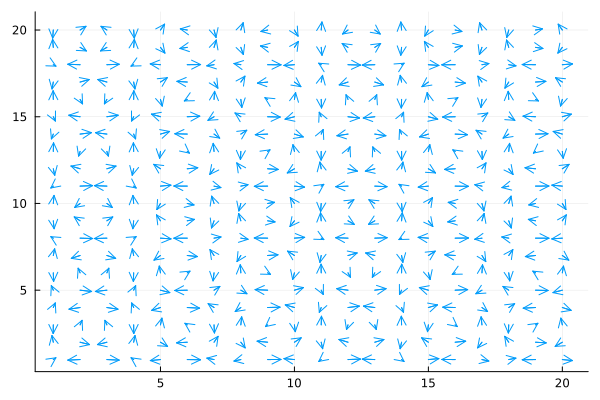

In [172]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end

dis_x=dis_x .- atom_x
dis_y=dis_y .- atom_y
p1=quiver(vec(atom_x),vec(atom_y),quiver=(vec(dis_x),vec(dis_y)))




In [173]:
#savefig(p1,"quiverplot.png")

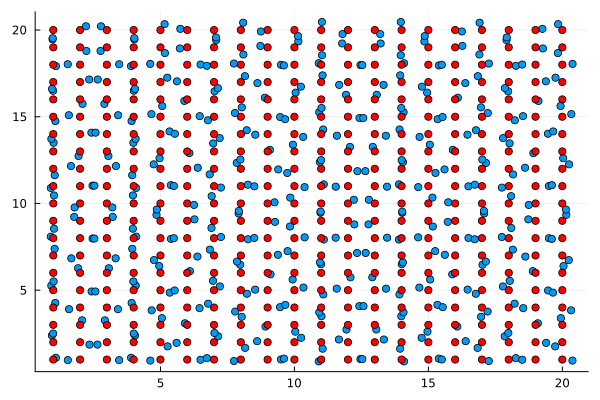

In [174]:
phonon_coor=st["phonon_coor"]
phonon_id=st["phonon_id"]
atom_x=zeros(Float64,Nx,Ny)
atom_y=zeros(Float64,Nx,Ny)
dis_x=zeros(Float64,Nx,Ny)
dis_y=zeros(Float64,Nx,Ny)

for ja in 1:Nx, jb in 1:Ny
    atom_x[ja,jb]=ja
    atom_y[ja,jb]=jb
    dis_x[ja,jb]=phonon_coor[phonon_id[ja,jb,1]]+ja
    dis_y[ja,jb]=phonon_coor[phonon_id[ja,jb,2]]+jb
    
end


p2=scatter(vec(dis_x),vec(dis_y))
scatter!(vec(atom_x),vec(atom_y),color=:red,legend=:false)

In [175]:
#savefig(p2,"atomplot.png")

In [176]:
sort(vec(dis_y)-vec(atom_y))

400-element Vector{Float64}:
 -0.5003226056615269
 -0.5003226056611672
 -0.500272596979034
 -0.5002725969787596
 -0.495909806649264
 -0.49590980664908635
 -0.4958554720383823
 -0.4958554720381123
 -0.46962198868759586
 -0.46962198868648386
  ⋮
  0.4654001983650353
  0.4981011537987037
  0.498101153799023
  0.49815265740086545
  0.498152657401274
  0.4986001708985386
  0.49860017089869046
  0.49865276373251444
  0.4986527637325793

In [177]:
sort(vec(sqrt.(dis_x.^2+dis_y.^2)))

400-element Vector{Float64}:
  1.5543829519127212
  1.8203948955521738
  2.5675210712543417
  2.6908117533562743
  3.0000147941562765
  3.2368120716580098
  3.5906958741735266
  3.8657495019436117
  4.056255024489249
  4.214812349649947
  ⋮
 26.21991915612423
 26.4251865084314
 26.51442454616092
 26.538831248855054
 27.020914847043876
 27.222448941562607
 27.239262843791863
 27.812340213711828
 28.415867132878855

In [178]:
sum(vec(sqrt.(dis_x.^2+dis_y.^2)))/(Nx*Ny)

15.95446319594168

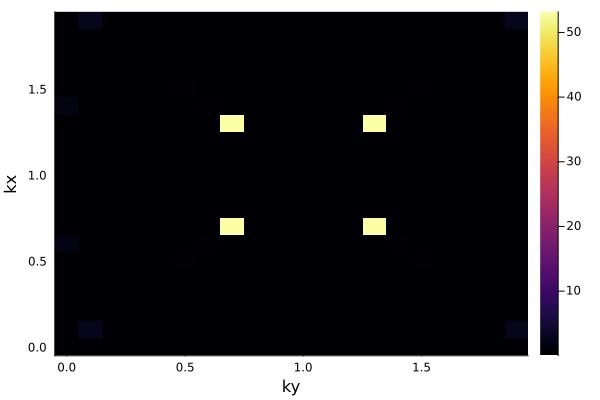

In [179]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_x=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_x[ja,jb]+=phonon_coor[phonon_id[jc,jd,1]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_x),xlabel="ky",ylabel="kx")

In [180]:
sort(vec(abs.(Fourier_mode_x)))

400-element Vector{Float64}:
  1.3602980852179094e-15
  1.5665021717344357e-15
  1.579035501732049e-15
  1.7422895603068216e-15
  1.7552312067201521e-15
  1.7566238096844442e-15
  2.3869795029440866e-15
  2.7851180782970636e-15
  3.0685057326902896e-15
  3.2207734746046803e-15
  ⋮
  1.5660002759212424
  2.638431750815339
  2.6384317508153665
  2.6387466991620414
  2.6387466991620503
 53.18694248874009
 53.186942488740115
 53.18700199304721
 53.18700199304722

In [181]:
findmax(abs.(Fourier_mode_x))

(53.18700199304722, CartesianIndex(8, 14))

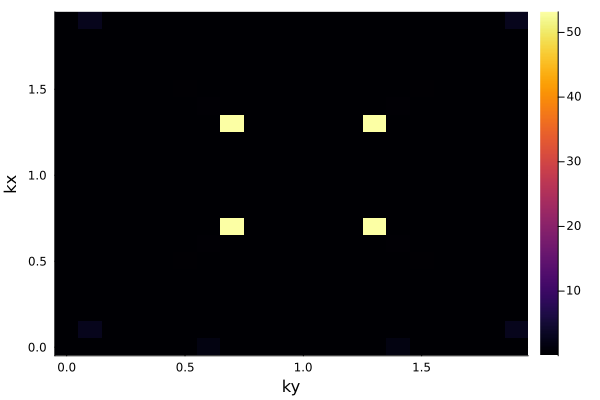

In [182]:
kx_space=2π*collect(0:1:Nx-1)/Nx
ky_space=2π*collect(0:1:Ny-1)/Ny
Fourier_mode_y=zeros(ComplexF64,length(kx_space),length(ky_space))
for ja in eachindex(kx_space), jb in eachindex(ky_space)
    kx=kx_space[ja]
    ky=ky_space[jb]
    for jc in 1:Nx, jd in 1:Ny, xp in -0:0, yp in -0:0
    Fourier_mode_y[ja,jb]+=phonon_coor[phonon_id[jc,jd,2]]*exp(-im*(kx*(jc+xp*Nx)+ky*(jd+yp*Ny)))
    end

end

heatmap(ky_space/pi,kx_space/pi,abs.(Fourier_mode_y),xlabel="ky",ylabel="kx")

In [183]:
findmax(abs.(Fourier_mode_y))

(53.18700206157843, CartesianIndex(14, 8))

In [188]:
Fourier_mode_y[8,14]

17.334502834869014 + 50.282921551618955im

In [189]:
Fourier_mode_x[8,14]

17.334502467032976 + 50.282921605937304im

In [190]:
Fourier_mode_y[14,8]

17.33450283486926 - 50.28292155161888im

In [191]:
Fourier_mode_x[14,8]

17.334502467033236 - 50.282921605937204im

In [192]:
Fourier_mode_y[8,8]

50.26486156479677 + 17.3866197750744im

In [193]:
Fourier_mode_x[8,8]

-50.26486163367638 - 17.386619460030563im